# 02. toy segmentation -- 픽셀 단위 타깃과 마스크의 특수 취급

`01_toy_cls.ipynb`의 target은 샘플당 스칼라 하나였다. Segmentation의 target은 `(H, W)` 텐서 --
이미지와 같은 공간 해상도를 갖는 정수 라벨 맵이다. 이 노트북은 이 target이 배치·transform·loss
경로에서 classification의 스칼라 라벨과 무엇이 다르게 취급되는지 확인한다.

In [1]:
import os
import sys


def find_repo_root(start):
    """Walk up from the notebook's own directory to the repository root (identified by the
    presence of `src/`), so `import src...` resolves regardless of where this notebook is run
    from (nbconvert executes with cwd set to the notebook's own directory)."""
    path = os.path.abspath(start)
    while not os.path.isdir(os.path.join(path, "src")):
        parent = os.path.dirname(path)
        if parent == path:
            raise RuntimeError("could not locate repository root (no 'src/' found above cwd)")
        path = parent
    return path


REPO_ROOT = find_repo_root(os.getcwd())
if REPO_ROOT not in sys.path:
    sys.path.insert(0, REPO_ROOT)
os.chdir(REPO_ROOT)

# Mirrors src/__main__.py: arm the offline guard before any module that might touch the
# network at import time, then import src.tasks so every @DATASETS/@MODELS/@ADAPTERS/...
# decorator across the 4 tasks (+ toy) actually runs and populates the registries. Until this
# import happens, every Registry in src.core.registry is empty.
from src.core.offline import enable_offline_guard

enable_offline_guard()
import src.tasks  # noqa: F401,E402

print("cwd:", os.getcwd())

import torch

cwd: /mnt/d/projects/nampluskr/00_review/260818_cv-boilerplate


## 데이터 -- `ToySegDataset`

`mask`는 `[0, num_classes)` 범위의 `long` 텐서이며 이미지와 같은 `(H, W)`다.

In [2]:
from src.core.registry import DATASETS

train_ds = DATASETS.build("toy_seg", root=".", split="train", transform=None,
                           image_size=(32, 32), num_classes=3)
image, mask = train_ds[0]
print("image:", image.shape, image.dtype)
print("mask: ", mask.shape, mask.dtype, "unique values:", torch.unique(mask).tolist())

image: torch.Size([3, 32, 32]) torch.float32
mask:  torch.Size([32, 32]) torch.int64 unique values: [0, 1, 2]


## 마스크에는 보간·정규화를 적용하지 않는다

`ToyDatasetBase.apply_transform`은 `image`에만 적용된다. `ToySegDataset.__getitem__`을 보면
`self.apply_transform(image)`는 이미지에만 호출되고, `mask`는 만들어진 그대로 반환된다.

In [3]:
import inspect

print(inspect.getsource(DATASETS.get("toy_seg")))

@DATASETS.register("toy_seg")
class ToySegDataset(ToyDatasetBase):
    def __init__(self, root, split, transform=None, num_samples=None, seed=42,
                 image_size=(32, 32), num_classes=3, **params):
        super().__init__(root, split, transform, num_samples, seed, **params)
        self.image_size = image_size
        self.num_classes = num_classes

    def __getitem__(self, idx):
        rng = item_rng(self.seed, self.split, idx)
        h, w = self.image_size
        image = torch.from_numpy(rng.standard_normal((3, h, w)).astype(np.float32))
        mask = torch.from_numpy(rng.integers(0, self.num_classes, size=(h, w)).astype(np.int64))
        return self.apply_transform(image), mask



실데이터 노트북(`tasks/02_segmentation.ipynb`)에서 다시 확인하겠지만, 이 원칙은 toy에서도
그대로다: 이미지는 리사이즈·정규화가 필요한 연속값(float)이므로 bilinear 보간이 자연스럽지만, 마스크는
클래스 인덱스(정수 카테고리)이므로 보간하면 존재하지 않는 클래스 값(예: 1.5)이 생겨버린다. 마스크에
리사이즈가 필요하면 `nearest` 방식만 쓸 수 있고, 정규화(평균/표준편차 빼기)는 애초에 의미가 없다.
`ToyDatasetBase`가 `apply_transform`을 이미지에만 거는 것은 이 사실을 코드로 강제한 것이다.

## `collate_fn` -- 여전히 기본 `default_collate`

Segmentation의 target도 배치 내에서 shape가 고정이므로 (`image_size`가 config에 고정되어 있어
모든 샘플의 마스크가 같은 `(H, W)`다 -- `num_classes`는 마스크 값의 *범위*만 정할 뿐 *shape*와는
무관하다), Classification과 마찬가지로 커스텀 `collate_fn`이 필요 없다.

In [4]:
from src.core.registry import ADAPTERS

ToySegAdapter = ADAPTERS.get("toy_seg")
adapter = ToySegAdapter(loss_fn=None, metrics={})
print("adapter.collate_fn():", adapter.collate_fn())

from torch.utils.data import DataLoader

loader = DataLoader(train_ds, batch_size=8, shuffle=False)
batch_images, batch_masks = next(iter(loader))
print("batch images:", batch_images.shape)
print("batch masks: ", batch_masks.shape, batch_masks.dtype)

adapter.collate_fn(): None
batch images: torch.Size([8, 3, 32, 32])
batch masks:  torch.Size([8, 32, 32]) torch.int64


`batch_masks`는 `(B, H, W)`다. Classification의 `batch_labels`가 `(B,)`였던 것과 대비된다 --
target의 차원 수 자체가 태스크마다 다르다는 것을 `Trainer`는 전혀 몰라도 된다. `nn.CrossEntropyLoss`가
`(B, C, H, W)` logits과 `(B, H, W)` long target을 그대로 받아들이는 PyTorch의 관례를 그대로
활용한다.

## 학습 -- 5 epoch, CPU, mIoU 모니터링

In [5]:
import os

from src.cli.commands import bind_class_names, build_components, build_dataset, build_transforms
from src.core.builders import build_dataloader, build_optimizer, build_scheduler
from src.core.config import resolve_config, validate_config
from src.core.context import RunContext
from src.core.engine import Trainer
from src.core.logger import MetricsCsvWriter, setup_logger

config = validate_config(resolve_config("configs/toy/toy_seg.yaml"))
run_dir = os.path.join("outputs", "notebooks", "02_toy_seg")
os.makedirs(run_dir, exist_ok=True)

ctx = RunContext(config, run_dir)
ctx.setup_seed()

transform_train, transform_eval = build_transforms(config)
model, adapter = build_components(config)
adapter.to(ctx.device)
train_ds = build_dataset(config, "train", transform_train)
valid_ds = build_dataset(config, "valid", transform_eval)
bind_class_names(adapter, train_ds)

train_loader = build_dataloader(train_ds, config["data"], "train", adapter, ctx.seed,
                                 config["runtime"]["device"])
valid_loader = build_dataloader(valid_ds, config["data"], "valid", adapter, ctx.seed,
                                 config["runtime"]["device"])
optimizer = build_optimizer(config["optim"], model)
scheduler = build_scheduler(config["optim"], optimizer)

logger = setup_logger(run_dir, "WARNING")
metrics_writer = MetricsCsvWriter(run_dir, [m["name"] for m in config["metrics"]])
trainer = Trainer(logger=logger, metrics_writer=metrics_writer,
                   checkpoint_dir=os.path.join(run_dir, "checkpoints"))

best = trainer.fit(model, adapter, train_loader, valid_loader, optimizer, scheduler, ctx)
print("best valid mIoU:", best)

best valid mIoU: 0.19822931289672852


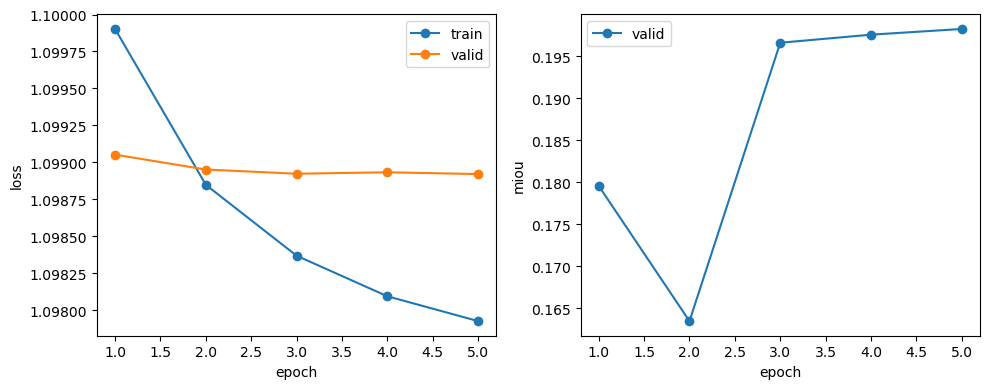

,epoch,split,loss,miou,lr,elapsed_sec
0,1,train,1.099902,NaN,0.001000,0.126474
1,1,valid,1.099052,0.179552,0.000000,0.020360
2,2,train,1.098847,NaN,0.000905,0.048553
3,2,valid,1.098951,0.163441,0.000000,0.018800
4,3,train,1.098367,NaN,0.000658,0.044637
5,3,valid,1.098922,0.196588,0.000000,0.016477
6,4,train,1.098093,NaN,0.000352,0.044203
7,4,valid,1.098932,0.197548,0.000000,0.019542
8,5,train,1.097925,NaN,0.000105,0.047331
9,5,valid,1.098920,0.198229,0.000000,0.017496


In [6]:
from notebooks.common import plot_training_curves

plot_training_curves(os.path.join(run_dir, "metrics_epoch.csv"), ["miou"])

## `predict_step` 출력 -- 샘플당 `(H, W)` 라벨 맵

Classification의 `predict_step`은 스칼라 라벨의 리스트였다. Segmentation은 샘플당 `(H, W)`
전체 픽셀 라벨을 반환한다 -- "샘플당 하나의 예측"이라는 계약(`TaskAdapter.predict_step`)은 같지만,
그 "하나"의 내용물 크기가 태스크마다 다르다.

In [7]:
model.eval()
sample_batch = next(iter(valid_loader))
with torch.no_grad():
    predictions = adapter.predict_step(model, sample_batch, ctx.device)

print("batch size:", sample_batch[0].shape[0], " predictions:", len(predictions))
print("prediction[0] shape:", len(predictions[0]), "x", len(predictions[0][0]))

batch size: 8  predictions: 8
prediction[0] shape: 32 x 32


## 요약

- `ToySegDataset`의 target은 이미지와 같은 공간 해상도의 `(H, W)` long 마스크다.
- `ToyDatasetBase.apply_transform`은 이미지에만 걸린다 -- 마스크에 보간·정규화를 적용하면 클래스
  인덱스라는 의미가 깨지기 때문이다.
- target의 차원이 스칼라에서 `(H, W)`로 바뀌어도 `collate_fn`은 여전히 기본값으로 충분하다 (배치
  내 shape가 고정이므로).

다음(`03_toy_det.ipynb`)은 target의 shape 자체가 샘플마다 달라지는(가변 길이) 경우를 다룬다 --
여기서부터 `collate_fn`을 오버라이드해야 한다.